# Desafío - Modelos de ensamble (Parte I)

Este notebook desarrolla el desafío de detección temprana de renuncias en una empresa de telecomunicaciones.

El objetivo es seguir una estructura ordenada:

1. Cargar y revisar la base `telecom_churn.csv`.
2. Analizar las variables con visualizaciones y matriz de correlación.
3. Entrenar un árbol de decisión base y luego mejorarlo con GridSearchCV.
4. Balancear las clases con SMOTE y entrenar un Bagging homogéneo.
5. Entrenar un Bagging heterogéneo usando la función facilitada `bagging_het` del archivo `util_bagging.py`.
6. Entrenar Random Forest con OOB, importancia de variables y métricas.
7. Ajustar Random Forest con búsqueda de grilla.
8. Identificar los 15 clientes con mayor propensión a renunciar.

## 1. Importación de librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

# Importamos la función facilitada para el Bagging heterogéneo
from util_bagging import bagging_het, bagging_het_predict

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carga de datos

El archivo `telecom_churn.csv` debe estar en la misma carpeta que este notebook.

In [2]:
df = pd.read_csv("telecom_churn.csv")
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [3]:
df.shape

(3333, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Churn,3333.0,0.144914,0.352067,0.0,0.00,0.00,0.00,1.00
AccountWeeks,3333.0,101.064806,39.822106,1.0,74.00,101.00,127.00,243.00
ContractRenewal,3333.0,0.903090,0.295879,0.0,1.00,1.00,1.00,1.00
DataPlan,3333.0,0.276628,0.447398,0.0,0.00,0.00,1.00,1.00
DataUsage,3333.0,0.816475,1.272668,0.0,0.00,0.00,1.78,5.40
CustServCalls,3333.0,1.562856,1.315491,0.0,1.00,1.00,2.00,9.00
DayMins,3333.0,179.775098,54.467389,0.0,143.70,179.40,216.40,350.80
DayCalls,3333.0,100.435644,20.069084,0.0,87.00,101.00,114.00,165.00
MonthlyCharge,3333.0,56.305161,16.426032,14.0,45.00,53.50,66.20,111.30
OverageFee,3333.0,10.051488,2.535712,0.0,8.33,10.07,11.77,18.19


In [6]:
df.isna().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

## 3. Análisis exploratorio

Primero revisamos la distribución de la variable objetivo `Churn`. Esto es importante porque, si las clases están desbalanceadas, un modelo podría predecir siempre la clase mayoritaria y aun así verse bien en `accuracy`, aunque realmente sería un modelo flojo para detectar renuncias.

Churn
0    2850
1     483
Name: count, dtype: int64
Tasa de renuncia: 14.49%


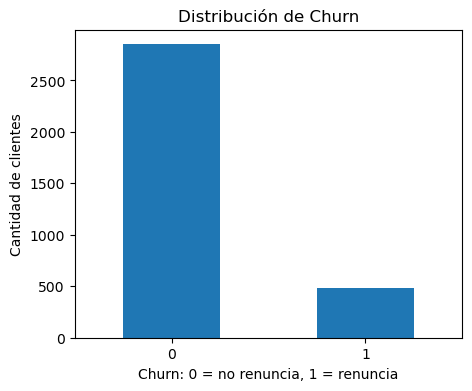

In [7]:
churn_counts = df["Churn"].value_counts().sort_index()
churn_rate = df["Churn"].mean()

print(churn_counts)
print(f"Tasa de renuncia: {churn_rate:.2%}")

plt.figure(figsize=(5, 4))
churn_counts.plot(kind="bar")
plt.title("Distribución de Churn")
plt.xlabel("Churn: 0 = no renuncia, 1 = renuncia")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

### 3.1 Visualización por variable

Se grafican histogramas para revisar rangos, concentración de valores y posibles patrones raros. No buscamos poesía visual: buscamos señales útiles para modelar.

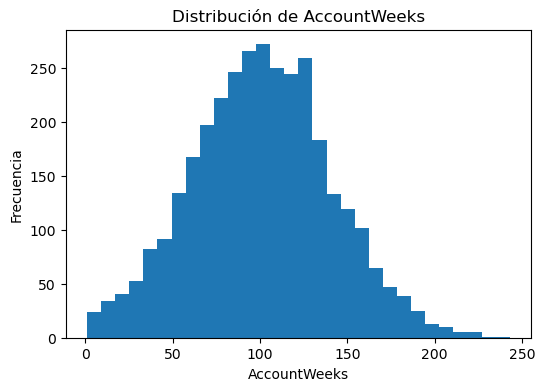

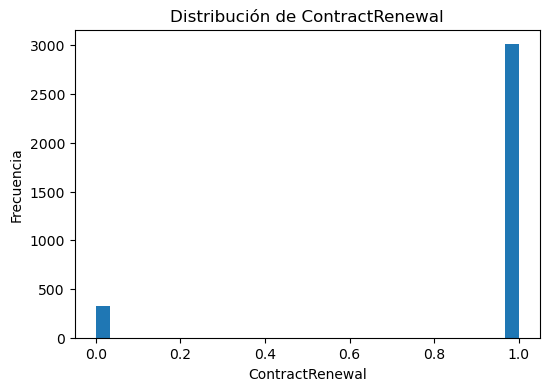

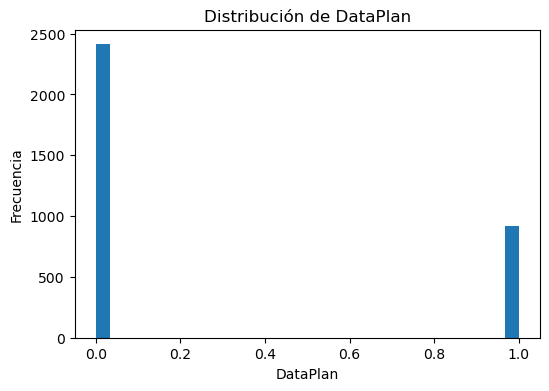

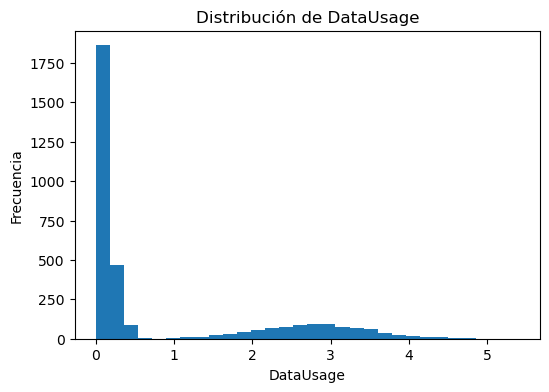

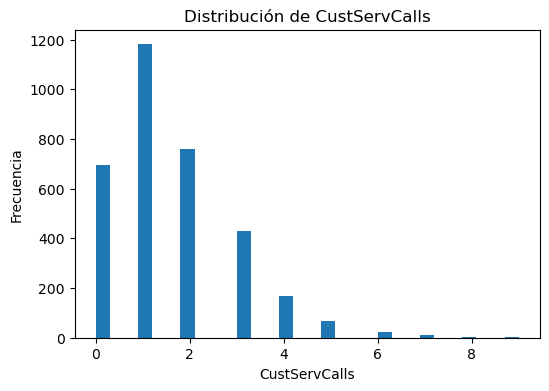

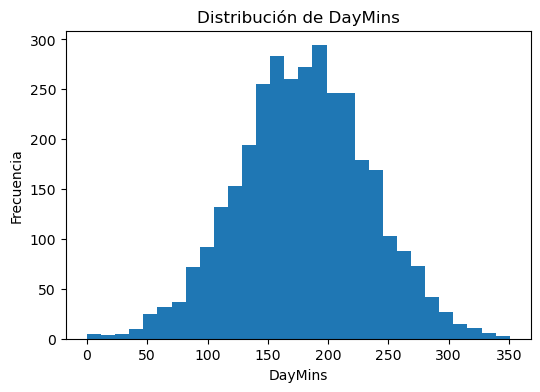

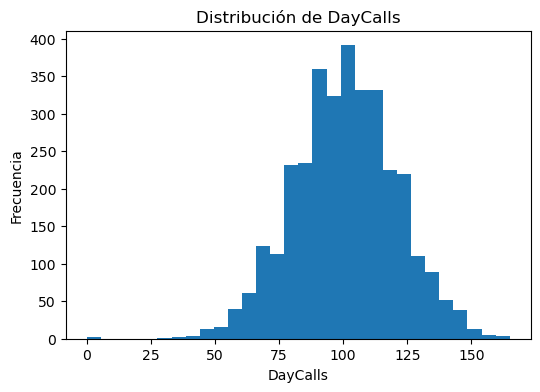

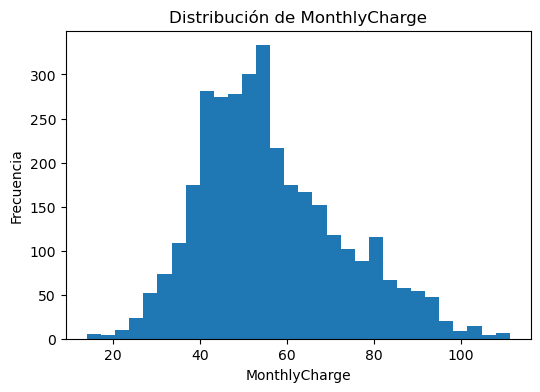

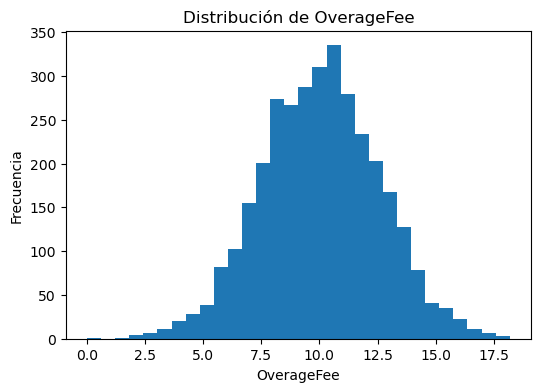

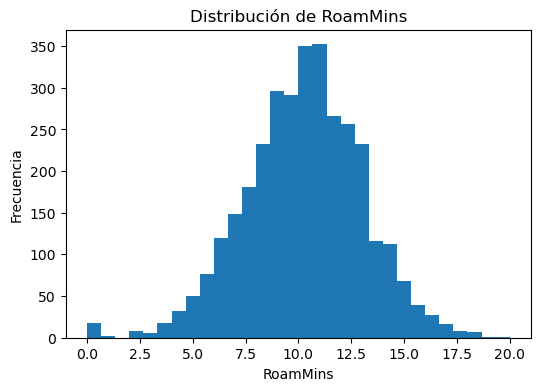

In [8]:
feature_cols = [col for col in df.columns if col != "Churn"]

for col in feature_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

### 3.2 Variables según Churn

Estas visualizaciones ayudan a ver si una variable separa bien a clientes que renuncian de clientes que no renuncian.

<Figure size 600x400 with 0 Axes>

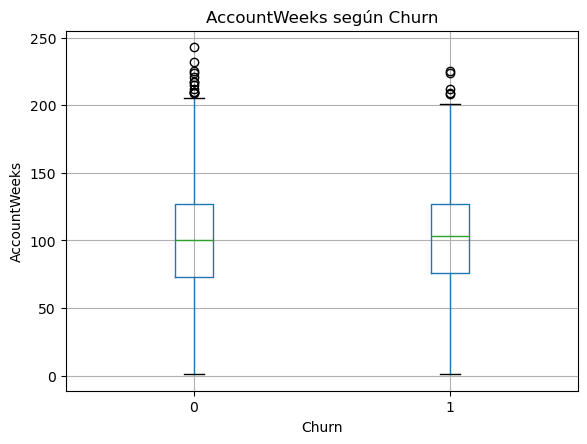

<Figure size 600x400 with 0 Axes>

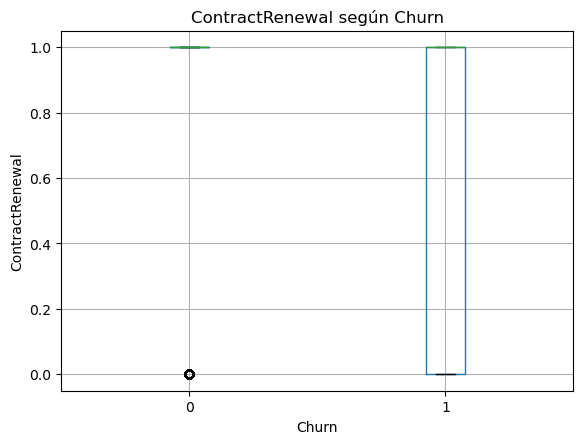

<Figure size 600x400 with 0 Axes>

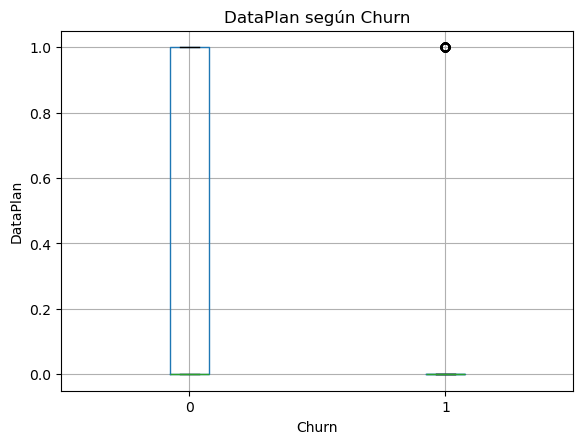

<Figure size 600x400 with 0 Axes>

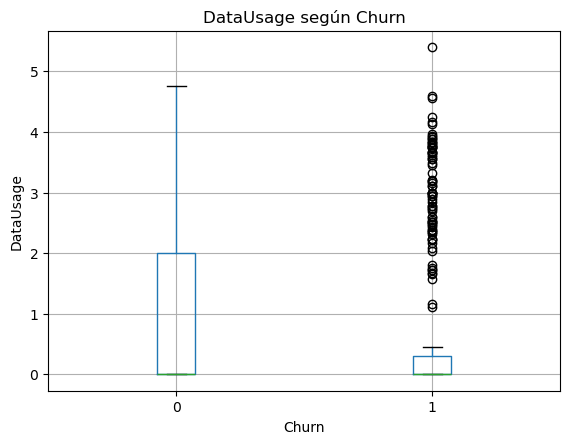

<Figure size 600x400 with 0 Axes>

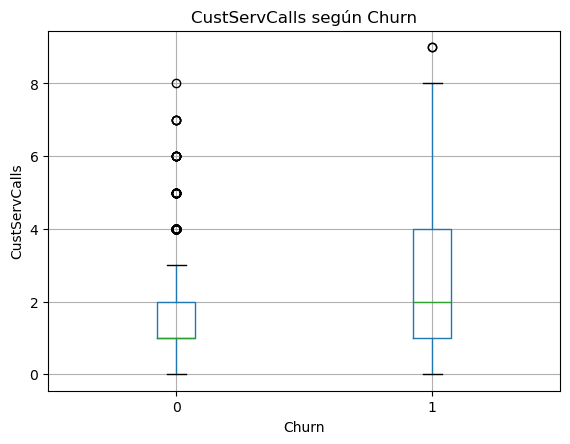

<Figure size 600x400 with 0 Axes>

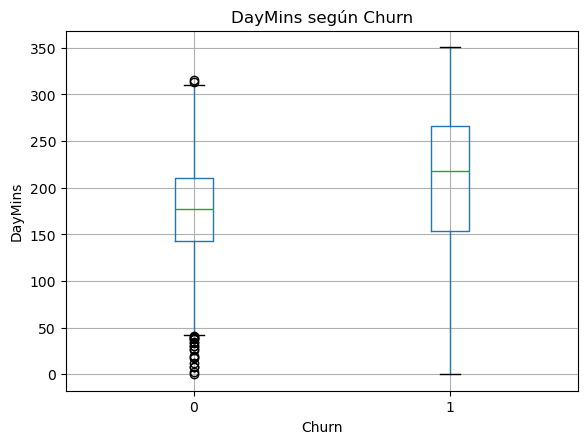

<Figure size 600x400 with 0 Axes>

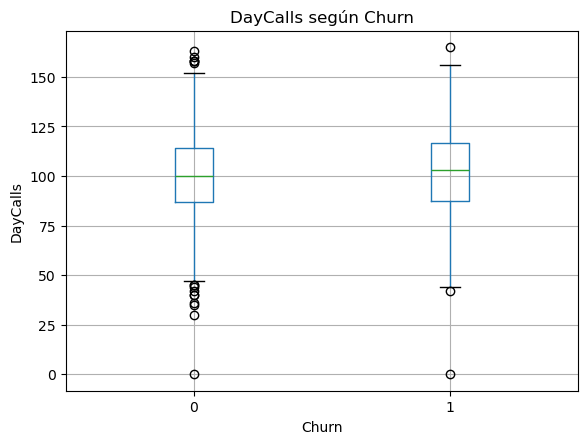

<Figure size 600x400 with 0 Axes>

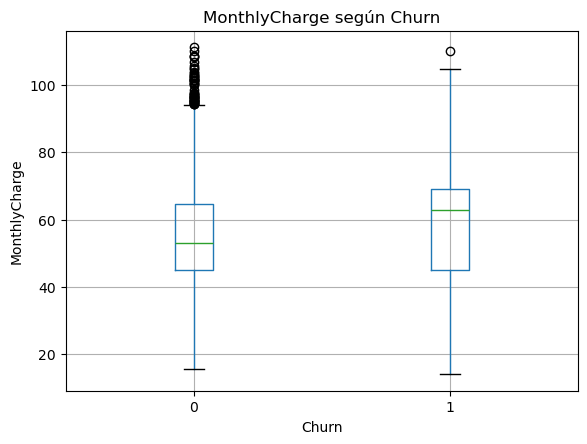

<Figure size 600x400 with 0 Axes>

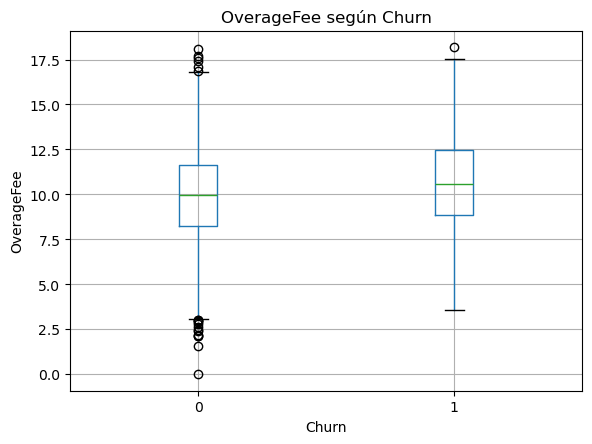

<Figure size 600x400 with 0 Axes>

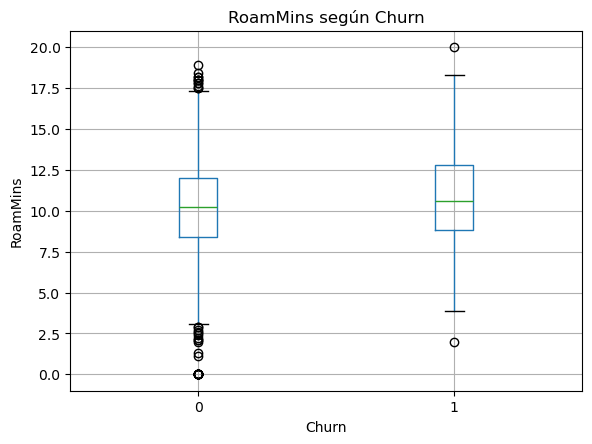

In [9]:
for col in feature_cols:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col, by="Churn")
    plt.title(f"{col} según Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

### 3.3 Matriz de correlación

La correlación permite revisar relaciones lineales entre variables. También ayuda a detectar variables muy relacionadas entre sí, lo que puede afectar algunos modelos.

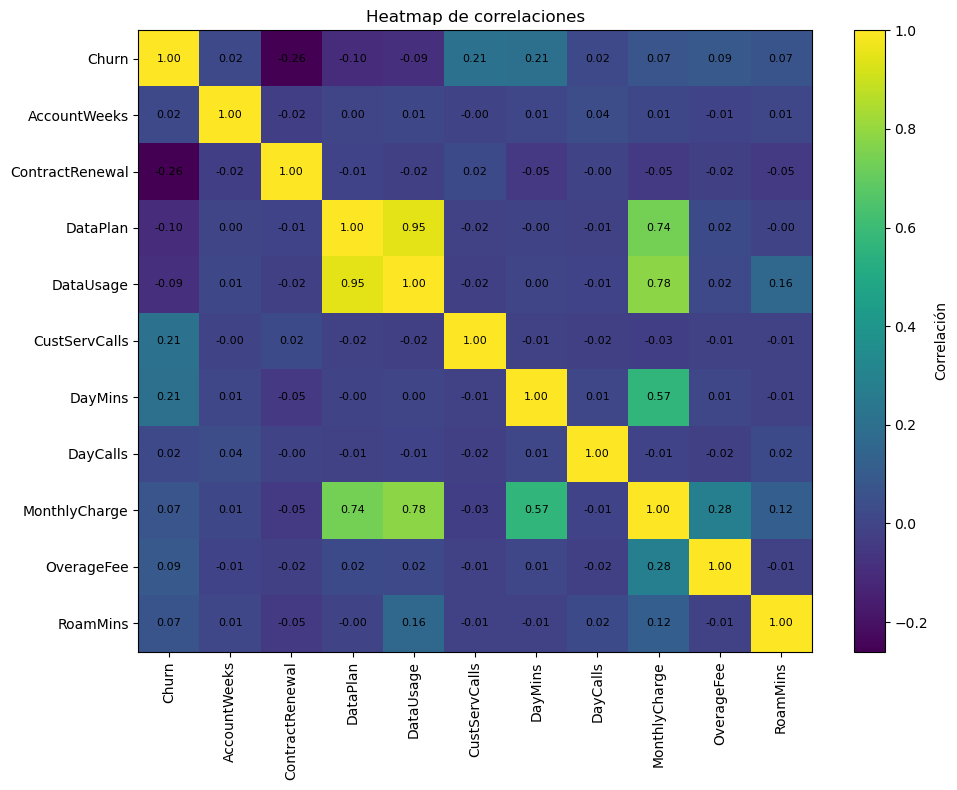

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Heatmap de correlaciones")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
corr["Churn"].sort_values(ascending=False)

## 4. Preparación de datos

Separamos variables predictoras (`X`) y variable objetivo (`y`). Luego dividimos en entrenamiento y test usando estratificación para mantener proporciones parecidas de `Churn` en ambos conjuntos.

In [11]:
X = df.drop(columns="Churn")
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, y_train.value_counts(normalize=True).round(3).to_dict())
print("Test:", X_test.shape, y_test.value_counts(normalize=True).round(3).to_dict())

Train: (2333, 10) {0: 0.855, 1: 0.145}
Test: (1000, 10) {0: 0.855, 1: 0.145}


### Funciones auxiliares de evaluación

Para evitar repetir código, se crean funciones para calcular métricas, mostrar matriz de confusión y graficar ROC cuando corresponda.

In [12]:
def obtener_metricas(y_real, y_pred):
    return pd.Series({
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1_score": f1_score(y_real, y_pred, zero_division=0)
    })


def evaluar_modelo(nombre, modelo, X_eval, y_eval, mostrar_reporte=True):
    y_pred = modelo.predict(X_eval)
    metricas = obtener_metricas(y_eval, y_pred)
    print(f"Métricas - {nombre}")
    display(metricas.to_frame().T)

    if mostrar_reporte:
        print(classification_report(y_eval, y_pred, zero_division=0))

    cm = confusion_matrix(y_eval, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    return metricas


def graficar_roc(nombre, y_real, y_score):
    fpr, tpr, _ = roc_curve(y_real, y_score)
    auc = roc_auc_score(y_real, y_score)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"Curva ROC - {nombre}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    return auc

## 5. Árbol de decisión base

Primero se entrena un árbol de decisión sin modificar hiperparámetros. Este modelo puede sobreajustar fácilmente, así que lo usamos como línea base.

Métricas - Árbol base - Train


,accuracy,precision,recall,f1_score
0,1.0,1.0,1.0,1.0


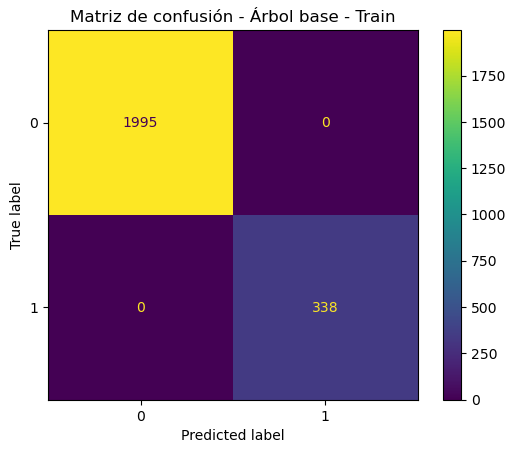

Métricas - Árbol base - Test


,accuracy,precision,recall,f1_score
0,0.878,0.578231,0.586207,0.582192


              precision    recall  f1-score   support

           0       0.93      0.93      0.93       855
           1       0.58      0.59      0.58       145

    accuracy                           0.88      1000
   macro avg       0.75      0.76      0.76      1000
weighted avg       0.88      0.88      0.88      1000



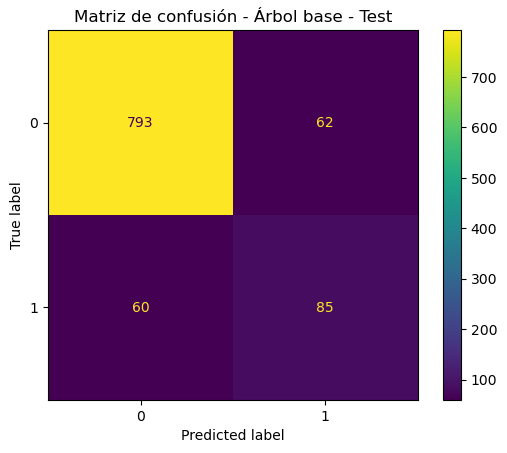

,accuracy,precision,recall,f1_score
train,1.000,1.000000,1.000000,1.000000
test,0.878,0.578231,0.586207,0.582192


In [13]:
tree_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_base.fit(X_train, y_train)

metricas_tree_base_train = evaluar_modelo("Árbol base - Train", tree_base, X_train, y_train, mostrar_reporte=False)
metricas_tree_base_test = evaluar_modelo("Árbol base - Test", tree_base, X_test, y_test)

pd.DataFrame([metricas_tree_base_train, metricas_tree_base_test], index=["train", "test"])

## 6. Árbol de decisión con búsqueda de grilla

Ahora se mejora el árbol usando validación cruzada con 5 folds. La idea es controlar el crecimiento del árbol para reducir overfitting.

In [14]:
param_grid_tree = {
    "max_depth": [5, 10, 15, 20, 25],
    "min_samples_split": [0.01, 0.02, 0.03, 0.04]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_tree,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_tree.best_params_)
print(f"Mejor F1 promedio CV: {grid_tree.best_score_:.4f}")

best_tree = grid_tree.best_estimator_

Mejores hiperparámetros: {'max_depth': 10, 'min_samples_split': 0.01}
Mejor F1 promedio CV: 0.6822


Métricas - Árbol ajustado - Train


,accuracy,precision,recall,f1_score
0,0.948564,0.868243,0.760355,0.810726


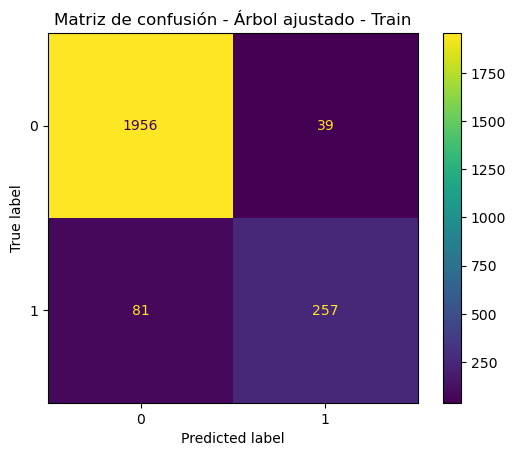

Métricas - Árbol ajustado - Test


,accuracy,precision,recall,f1_score
0,0.924,0.780488,0.662069,0.716418


              precision    recall  f1-score   support

           0       0.94      0.97      0.96       855
           1       0.78      0.66      0.72       145

    accuracy                           0.92      1000
   macro avg       0.86      0.82      0.84      1000
weighted avg       0.92      0.92      0.92      1000



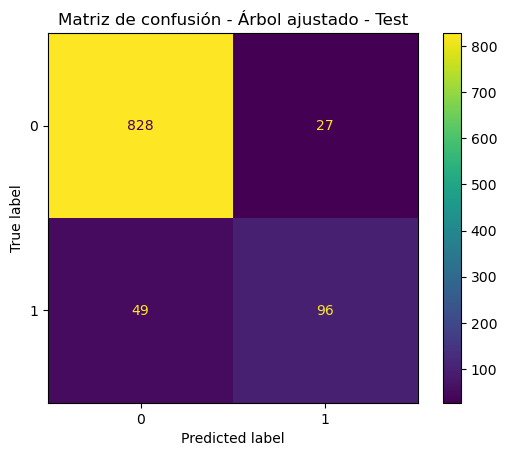

,accuracy,precision,recall,f1_score
train,0.948564,0.868243,0.760355,0.810726
test,0.924000,0.780488,0.662069,0.716418


In [15]:
metricas_tree_grid_train = evaluar_modelo("Árbol ajustado - Train", best_tree, X_train, y_train, mostrar_reporte=False)
metricas_tree_grid_test = evaluar_modelo("Árbol ajustado - Test", best_tree, X_test, y_test)

pd.DataFrame([metricas_tree_grid_train, metricas_tree_grid_test], index=["train", "test"])

## 7. Balanceo con SMOTE

Como la clase de renuncia suele ser minoritaria, se aplica SMOTE solo sobre entrenamiento. Jamás sobre test, porque sería como mirar la prueba antes de darla.

In [17]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Antes de SMOTE:")
print(y_train.value_counts())
print("Después de SMOTE:")
print(y_train_smote.value_counts())

Antes de SMOTE:
Churn
0    1995
1     338
Name: count, dtype: int64
Después de SMOTE:
Churn
0    1995
1    1995
Name: count, dtype: int64


## 8. Bagging homogéneo con 200 estimadores

Se entrena un Bagging usando árboles de decisión como estimadores base.

Métricas - Bagging homogéneo - Test


,accuracy,precision,recall,f1_score
0,0.894,0.608939,0.751724,0.67284


              precision    recall  f1-score   support

           0       0.96      0.92      0.94       855
           1       0.61      0.75      0.67       145

    accuracy                           0.89      1000
   macro avg       0.78      0.83      0.80      1000
weighted avg       0.91      0.89      0.90      1000



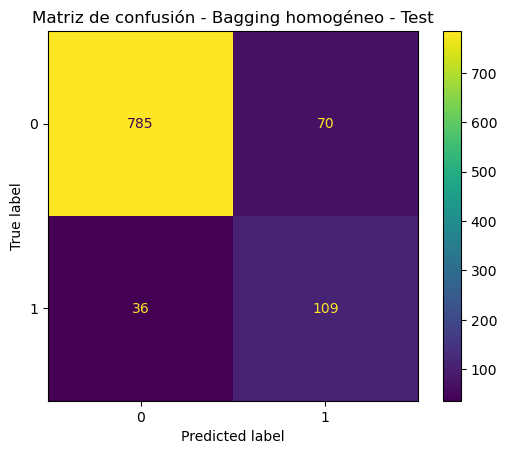

In [18]:
bagging_tree = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=200,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

bagging_tree.fit(X_train_smote, y_train_smote)
metricas_bagging_tree_test = evaluar_modelo("Bagging homogéneo - Test", bagging_tree, X_test, y_test)

## 9. Bagging heterogéneo con función facilitada

Se usa la función `bagging_het` del archivo `util_bagging.py`. Los estimadores base solicitados son:

- Regresión Logística
- Árbol de decisión
- SVM con kernel `rbf`
- SVM con kernel `sigmoid`

Primero se evalúa cada modelo por separado. Luego se repite en la bolsa el modelo con mejor `f1-score`, para darle más probabilidad de ser seleccionado en el ensamble.

In [19]:
def crear_modelo(tipo):
    if tipo == "logistic":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ])
    if tipo == "tree":
        return DecisionTreeClassifier(random_state=RANDOM_STATE)
    if tipo == "svm_rbf":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", random_state=RANDOM_STATE))
        ])
    if tipo == "svm_sigmoid":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="sigmoid", random_state=RANDOM_STATE))
        ])
    raise ValueError("Tipo de modelo no reconocido")

modelos_base = {
    "logistic": crear_modelo("logistic"),
    "tree": crear_modelo("tree"),
    "svm_rbf": crear_modelo("svm_rbf"),
    "svm_sigmoid": crear_modelo("svm_sigmoid")
}

resultados_base = []

for nombre, modelo in modelos_base.items():
    modelo.fit(X_train_smote, y_train_smote)
    pred = modelo.predict(X_test)
    metricas = obtener_metricas(y_test, pred)
    metricas.name = nombre
    resultados_base.append(metricas)

resultados_base_df = pd.DataFrame(resultados_base)
resultados_base_df

,accuracy,precision,recall,f1_score
logistic,0.773,0.356643,0.703448,0.473318
tree,0.853,0.495327,0.731034,0.590529
svm_rbf,0.860,0.511737,0.751724,0.608939
svm_sigmoid,0.547,0.160793,0.503448,0.243740


In [20]:
mejor_modelo_nombre = resultados_base_df["f1_score"].idxmax()
print("Modelo con mejor F1:", mejor_modelo_nombre)

# Bolsa inicial con los cuatro modelos solicitados
tipos_estimadores = ["logistic", "tree", "svm_rbf", "svm_sigmoid"]

# Calibración simple de importancia: repetimos 2 veces adicionales el mejor modelo.
# Así la función bagging_het tiene mayor probabilidad de seleccionarlo en cada bootstrap.
tipos_estimadores_calibrados = tipos_estimadores + [mejor_modelo_nombre, mejor_modelo_nombre]

estimadores_heterogeneos = [crear_modelo(tipo) for tipo in tipos_estimadores_calibrados]

print("Estimadores usados en la bolsa:")
print(tipos_estimadores_calibrados)

Modelo con mejor F1: svm_rbf
Estimadores usados en la bolsa:
['logistic', 'tree', 'svm_rbf', 'svm_sigmoid', 'svm_rbf', 'svm_rbf']


,accuracy,precision,recall,f1_score
0,0.866,0.525822,0.772414,0.625698


              precision    recall  f1-score   support

           0       0.96      0.88      0.92       855
           1       0.53      0.77      0.63       145

    accuracy                           0.87      1000
   macro avg       0.74      0.83      0.77      1000
weighted avg       0.90      0.87      0.88      1000



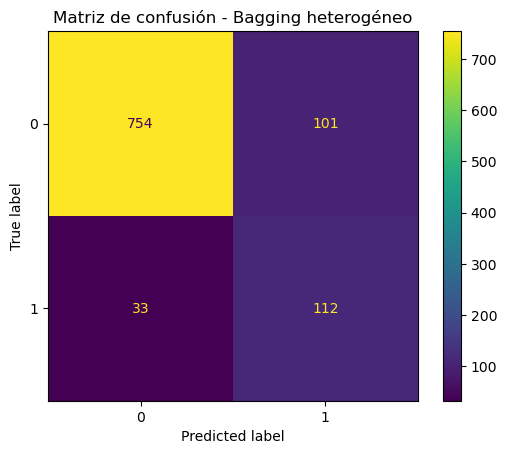

Cantidad de índices OOB distintos acumulados: 3990


In [21]:
T = 200

trained_models_het, yhat_test_het, yhat_out_het, idx_oob_het = bagging_het(
    X_train_smote,
    y_train_smote,
    T,
    estimadores_heterogeneos,
    X_test
)

# La función retorna predicciones como float; las pasamos a int para evaluar.
yhat_out_het = yhat_out_het.astype(int)

metricas_bagging_het_test = obtener_metricas(y_test.reset_index(drop=True), yhat_out_het)
display(metricas_bagging_het_test.to_frame().T)

print(classification_report(y_test.reset_index(drop=True), yhat_out_het, zero_division=0))

cm = confusion_matrix(y_test.reset_index(drop=True), yhat_out_het)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Matriz de confusión - Bagging heterogéneo")
plt.show()

print(f"Cantidad de índices OOB distintos acumulados: {len(idx_oob_het)}")

## 10. Random Forest con 45 estimadores y OOB

Se entrena un Random Forest con `n_estimators=45`. Además se activa `oob_score=True` para estimar el desempeño usando observaciones fuera de bolsa.

OOB accuracy estimada: 0.9258
Métricas - Random Forest 45 - Test


,accuracy,precision,recall,f1_score
0,0.929,0.808333,0.668966,0.732075


              precision    recall  f1-score   support

           0       0.95      0.97      0.96       855
           1       0.81      0.67      0.73       145

    accuracy                           0.93      1000
   macro avg       0.88      0.82      0.85      1000
weighted avg       0.93      0.93      0.93      1000



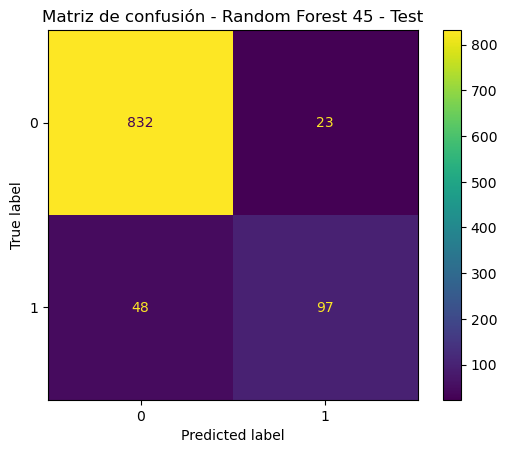

In [22]:
rf_45 = RandomForestClassifier(
    n_estimators=45,
    oob_score=True,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_45.fit(X_train, y_train)

print(f"OOB accuracy estimada: {rf_45.oob_score_:.4f}")
metricas_rf_45_test = evaluar_modelo("Random Forest 45 - Test", rf_45, X_test, y_test)

In [23]:
importancias_rf_45 = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": rf_45.feature_importances_
}).sort_values("importancia", ascending=False)

top4_rf_45 = importancias_rf_45.head(4)
top4_rf_45

,variable,importancia
5,DayMins,0.193813
7,MonthlyCharge,0.166603
4,CustServCalls,0.138815
8,OverageFee,0.092467


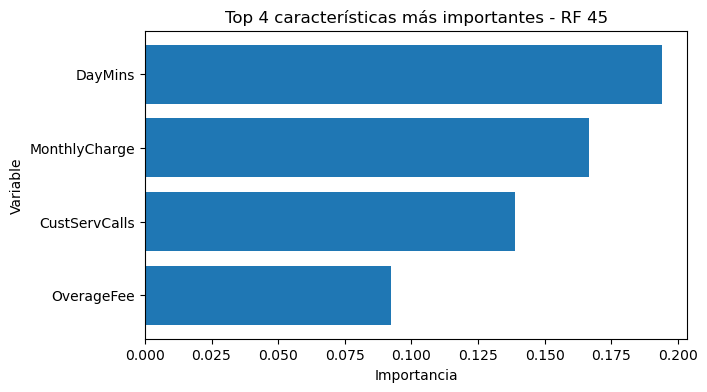

In [24]:
plt.figure(figsize=(7, 4))
plt.barh(top4_rf_45["variable"][::-1], top4_rf_45["importancia"][::-1])
plt.title("Top 4 características más importantes - RF 45")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## 11. Random Forest con búsqueda de grilla

Se prueban valores de `n_estimators` desde 50 hasta 190 con paso de 10, completando 15 valores. También se evalúa `max_features` con `sqrt`, `log2` y `None`.

In [25]:
param_grid_rf = {
    "n_estimators": list(range(50, 200, 10)),
    "max_features": ["sqrt", "log2", None]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        oob_score=True,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Mejor F1 promedio CV: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
print(f"OOB accuracy estimada del mejor RF: {best_rf.oob_score_:.4f}")

Mejores hiperparámetros: {'max_features': 'sqrt', 'n_estimators': 150}
Mejor F1 promedio CV: 0.7420
OOB accuracy estimada del mejor RF: 0.9357


Métricas - Random Forest ajustado - Test


,accuracy,precision,recall,f1_score
0,0.937,0.866071,0.668966,0.754864


              precision    recall  f1-score   support

           0       0.95      0.98      0.96       855
           1       0.87      0.67      0.75       145

    accuracy                           0.94      1000
   macro avg       0.91      0.83      0.86      1000
weighted avg       0.93      0.94      0.93      1000



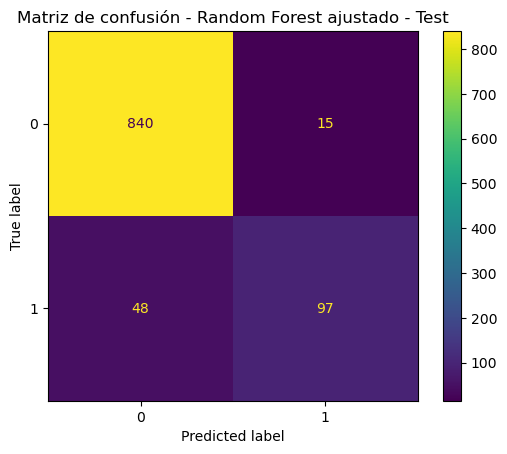

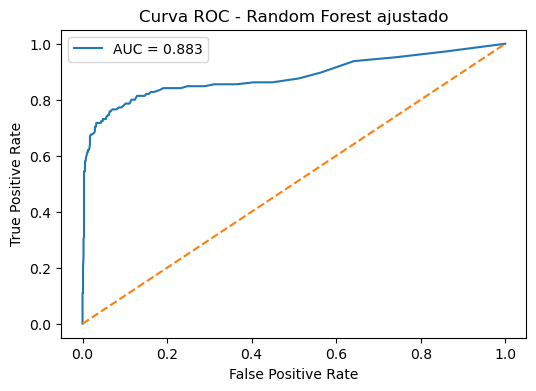

AUC Random Forest ajustado: 0.8827


In [26]:
metricas_best_rf_test = evaluar_modelo("Random Forest ajustado - Test", best_rf, X_test, y_test)

y_score_best_rf = best_rf.predict_proba(X_test)[:, 1]
auc_best_rf = graficar_roc("Random Forest ajustado", y_test, y_score_best_rf)
print(f"AUC Random Forest ajustado: {auc_best_rf:.4f}")

In [27]:
importancias_best_rf = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": best_rf.feature_importances_
}).sort_values("importancia", ascending=False)

top4_best_rf = importancias_best_rf.head(4)
top4_best_rf

,variable,importancia
5,DayMins,0.200969
7,MonthlyCharge,0.151298
4,CustServCalls,0.143732
8,OverageFee,0.099974


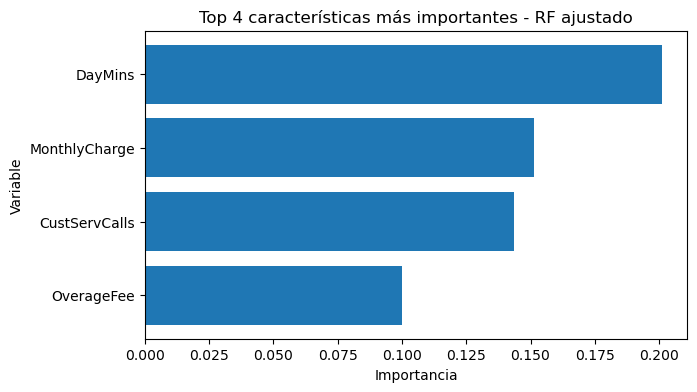

In [28]:
plt.figure(figsize=(7, 4))
plt.barh(top4_best_rf["variable"][::-1], top4_best_rf["importancia"][::-1])
plt.title("Top 4 características más importantes - RF ajustado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

### 11.1 Análisis de importancia de variables

Las variables más importantes tienen sentido si se relacionan con señales de comportamiento del cliente. Por ejemplo, muchas llamadas a servicio al cliente (`CustServCalls`) pueden indicar problemas o insatisfacción. También variables de cobro y uso, como `MonthlyCharge`, `DayMins`, `OverageFee` o `DataUsage`, pueden explicar renuncia si el cliente percibe alto costo o bajo beneficio.

La interpretación exacta debe revisarse con el resultado del ranking anterior, porque la importancia final depende de los datos y del ajuste del modelo.

## 12. Comparación general de modelos

In [29]:
resumen_modelos = pd.DataFrame([
    metricas_tree_base_test.rename("Árbol base"),
    metricas_tree_grid_test.rename("Árbol ajustado"),
    metricas_bagging_tree_test.rename("Bagging homogéneo"),
    metricas_bagging_het_test.rename("Bagging heterogéneo"),
    metricas_rf_45_test.rename("Random Forest 45"),
    metricas_best_rf_test.rename("Random Forest ajustado")
])

resumen_modelos.sort_values("f1_score", ascending=False)

,accuracy,precision,recall,f1_score
Random Forest ajustado,0.937,0.866071,0.668966,0.754864
Random Forest 45,0.929,0.808333,0.668966,0.732075
Árbol ajustado,0.924,0.780488,0.662069,0.716418
Bagging homogéneo,0.894,0.608939,0.751724,0.672840
Bagging heterogéneo,0.866,0.525822,0.772414,0.625698
Árbol base,0.878,0.578231,0.586207,0.582192


## 13. Top 15 clientes con mayor propensión a renunciar

Usamos el Random Forest ajustado para calcular la probabilidad de pertenecer a la clase `Churn = 1`. Luego se ordenan los clientes de mayor a menor propensión.

In [30]:
propension = best_rf.predict_proba(X)[:, 1]

top15_clientes = df.copy()
top15_clientes["propension_renuncia"] = propension
top15_clientes["cliente_id"] = top15_clientes.index

top15_clientes = top15_clientes.sort_values("propension_renuncia", ascending=False)

columnas_top15 = ["cliente_id", "propension_renuncia", "Churn"] + list(X.columns)
top15_clientes[columnas_top15].head(15)

,cliente_id,propension_renuncia,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
2267,2267,1.000000,1,29,1,0,0.00,2,313.2,103,72.0,10.82,12.8
1078,1078,1.000000,1,80,1,0,0.00,0,322.3,113,74.0,11.10,6.7
2647,2647,1.000000,1,116,1,0,0.00,0,288.0,120,71.0,12.79,13.4
975,975,1.000000,1,129,1,0,0.00,0,334.3,118,74.0,9.61,10.4
2708,2708,1.000000,1,132,1,0,0.00,1,291.2,104,70.0,11.71,8.9
605,605,1.000000,1,112,1,0,0.00,2,335.5,77,76.0,10.63,12.7
3072,3072,1.000000,1,75,1,0,0.00,0,305.1,106,68.0,9.40,8.5
1878,1878,1.000000,1,39,1,0,0.00,1,295.4,126,70.0,11.61,11.5
117,117,0.993333,1,74,1,0,0.21,1,282.5,114,69.1,11.00,9.4
332,332,0.993333,1,86,1,0,0.30,7,128.3,121,42.0,9.86,12.2


## 14. Conclusiones

- La base presenta un problema de clasificación binaria: predecir si un cliente renuncia o no.
- La clase `Churn = 1` es la más relevante para el negocio, porque representa clientes que podrían abandonar la compañía.
- El árbol base sirve como referencia, pero puede sobreajustar. Por eso se ajusta con grilla.
- SMOTE ayuda a que los modelos no ignoren la clase minoritaria.
- El Bagging homogéneo reduce varianza al combinar muchos árboles.
- El Bagging heterogéneo usa modelos distintos y se calibra repitiendo el modelo base con mejor F1.
- Random Forest entrega buen rendimiento y además permite interpretar variables importantes.
- El ranking de propensión permite priorizar clientes para acciones de retención.